# Wine Quality Classification using K-Nearest Neighbors (KNN)

This notebook demonstrates a complete machine learning workflow to classify wine types using the Scikit-Learn Wine dataset. The process includes exploratory data analysis, data preprocessing with scaling pipelines, and hyperparameter optimization for the KNN algorithm.

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.datasets import load_wine

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score

from sklearn.metrics import confusion_matrix,classification_report

## 1. Data Acquisition
We load the dataset directly into a Pandas DataFrame to facilitate exploration and manipulation.

In [56]:
df = load_wine(as_frame=True).frame

df.sample(5)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
101,12.60,1.34,1.90,18.5,88.0,1.45,1.36,0.29,1.35,2.45,1.04,2.77,562.0,1
31,13.58,1.66,2.36,19.1,106.0,2.86,3.19,0.22,1.95,6.90,1.09,2.88,1515.0,0
86,12.16,1.61,2.31,22.8,90.0,1.78,1.69,0.43,1.56,2.45,1.33,2.26,495.0,1
34,13.51,1.80,2.65,19.0,110.0,2.35,2.53,0.29,1.54,4.20,1.10,2.87,1095.0,0
147,12.87,4.61,2.48,21.5,86.0,1.70,0.65,0.47,0.86,7.65,0.54,1.86,625.0,2


## 2. Exploratory Data Analysis (EDA)
Understanding the data structure, statistical distribution, and class balance is crucial before modeling.

In [57]:
df.shape

(178, 14)

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

In [59]:
df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


<Axes: xlabel='target', ylabel='count'>

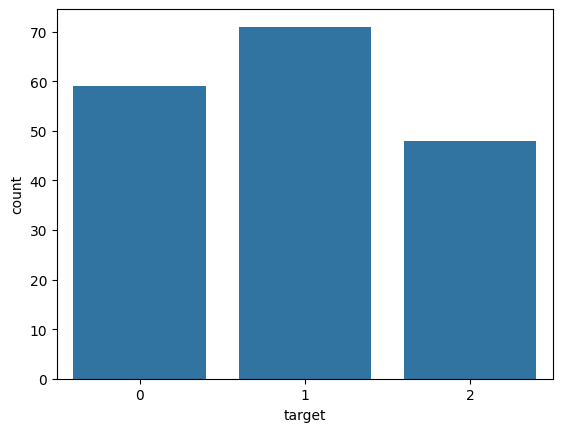

In [60]:
sns.countplot(data= df , x='target')

## 3. Data Splitting
We separate the features from the target variable and perform a stratified split to maintain class proportions in both training and testing sets.

In [61]:
X = df.drop(['target'],axis=1)
y = df['target']

X_train , X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [62]:
X_train

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
36,13.28,1.64,2.84,15.5,110.0,2.60,2.68,0.34,1.36,4.60,1.09,2.78,880.0
30,13.73,1.50,2.70,22.5,101.0,3.00,3.25,0.29,2.38,5.70,1.19,2.71,1285.0
26,13.39,1.77,2.62,16.1,93.0,2.85,2.94,0.34,1.45,4.80,0.92,3.22,1195.0
12,13.75,1.73,2.41,16.0,89.0,2.60,2.76,0.29,1.81,5.60,1.15,2.90,1320.0
148,13.32,3.24,2.38,21.5,92.0,1.93,0.76,0.45,1.25,8.42,0.55,1.62,650.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
142,13.52,3.17,2.72,23.5,97.0,1.55,0.52,0.50,0.55,4.35,0.89,2.06,520.0
87,11.65,1.67,2.62,26.0,88.0,1.92,1.61,0.40,1.34,2.60,1.36,3.21,562.0
34,13.51,1.80,2.65,19.0,110.0,2.35,2.53,0.29,1.54,4.20,1.10,2.87,1095.0
163,12.96,3.45,2.35,18.5,106.0,1.39,0.70,0.40,0.94,5.28,0.68,1.75,675.0


## 4. Model Pipeline & Training
Using a `Pipeline` ensures that the `StandardScaler` is fitted only on the training data, preventing data leakage during the KNN training process.

In [63]:
y_train.nunique()

3

In [64]:
knn_model = Pipeline(
    steps=[
        ('scaler',StandardScaler()),
        ('model',KNeighborsClassifier(n_neighbors=15,metric='minkowski',p=2))
    ]
)
knn_model.fit(X_train,y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', KNeighborsClassifier(n_neighbors=15))])

## 5. Model Evaluation
We evaluate the model's performance using standard metrics including Accuracy, Confusion Matrix, and a detailed Classification Report.

In [65]:
y_pred = knn_model.predict(X_test)
y_pred

array([0, 2, 0, 1, 1, 0, 0, 1, 1, 2, 1, 2, 0, 2, 0, 1, 1, 0, 1, 0, 1, 1,
       0, 0, 1, 1, 0, 2, 1, 2, 0, 2, 1, 2, 2, 2])

In [66]:
accuracy = accuracy_score(y_test,y_pred)
print(accuracy)

1.0


In [67]:
conf_mat = confusion_matrix(y_test,y_pred)
conf_mat


array([[12,  0,  0],
       [ 0, 14,  0],
       [ 0,  0, 10]])

In [68]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



## 6. Hyperparameter Tuning & Error Analysis
To find the optimal value for `k`, we iterate through a range of neighbors and compare the performance using different distance metrics (Euclidean vs. Manhattan).

simu

In [69]:
# Euclidean Distance (p=2) Analysis
euclidean_performance = []
euclidean_acc = []

for k in range(5, 30):
    knn_pipeline = Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier(n_neighbors=k, metric='minkowski', p=2))
    ])
    knn_pipeline.fit(X_train, y_train)
    y_pred = knn_pipeline.predict(X_test)

    score = accuracy_score(y_test, y_pred)
    euclidean_acc.append(score)
    euclidean_performance.append({
        'k': k,
        'accuracy': score,
        'precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'recall': recall_score(y_test, y_pred, average='weighted', zero_division=0)
    })

### Case 1: Minkowski Distance (p=2, Euclidean)
Visualizing accuracy trends for different K values using the Euclidean distance metric.

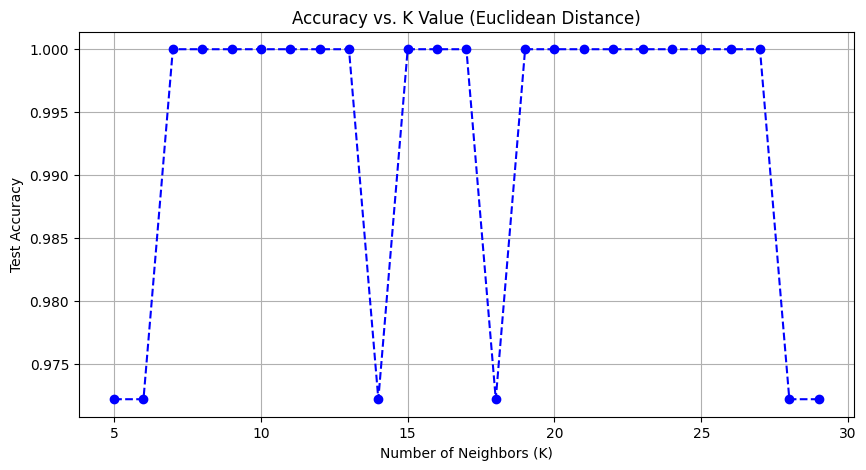

In [70]:
plt.figure(figsize=(10, 5))
plt.plot(range(5, 30), euclidean_acc, marker='o', linestyle='--', color='b')
plt.title('Accuracy vs. K Value (Euclidean Distance)')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Test Accuracy')
plt.grid(True)
plt.show()

### Case 2: Minkowski Distance (p=1, Manhattan)
Comparing performance when using the Manhattan distance metric across the same K range.

In [71]:
# Manhattan Distance (p=1) Analysis
manhattan_performance = []
manhattan_acc = []

for k in range(5, 30):
    knn_pipeline = Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier(n_neighbors=k, metric='minkowski', p=1))
    ])
    knn_pipeline.fit(X_train, y_train)
    y_pred = knn_pipeline.predict(X_test)

    score = accuracy_score(y_test, y_pred)
    manhattan_acc.append(score)
    manhattan_performance.append({
        'k': k,
        'accuracy': score,
        'precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'recall': recall_score(y_test, y_pred, average='weighted', zero_division=0)
    })

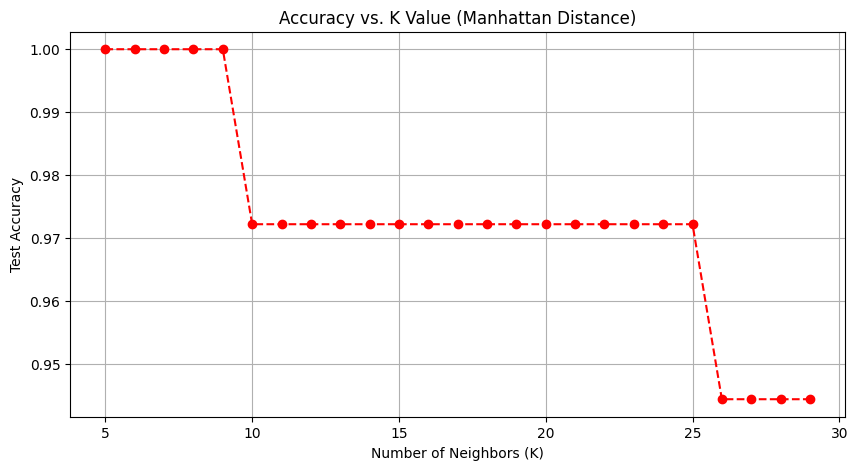

In [72]:
plt.figure(figsize=(10, 5))
plt.plot(range(5, 30), manhattan_acc, marker='o', linestyle='--', color='r')
plt.title('Accuracy vs. K Value (Manhattan Distance)')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Test Accuracy')
plt.grid(True)
plt.show()